# Fake News Detection Using Machine Learning

## Introduction

Fake news has become a major problem in the digital age, where misleading or false information can spread quickly through online platforms, social media, and news websites. The goal of this project is to build a machine learning system that can classify a news article as either **Fake News** or **True News** based on its textual content.

In this project, the dataset is loaded directly inside the Google Colab runtime using KaggleHub. This means there is no need to manually upload the dataset or download it to a local computer. The project uses the Fake and Real News Dataset, which contains two files: `Fake.csv` and `True.csv`.

The title and body text of each news article are combined to create a stronger input feature. The text is then cleaned by removing URLs, HTML tags, special characters, and extra spaces. After preprocessing, the text data is converted into numerical form using **TF-IDF Vectorization**, which helps machine learning models understand the importance of words and phrases in the articles.

Several machine learning models are trained and compared, including **Logistic Regression**, **Linear Support Vector Machine**, **Passive Aggressive Classifier**, and **Naive Bayes**. The best-performing model is selected based on accuracy and evaluated using a classification report, confusion matrix, and cross-validation.

Finally, the notebook includes a manual testing section where users can paste their own news article and get a prediction from the trained model.

## Objectives

- Load the fake and true news dataset directly inside Google Colab.
- Preprocess and clean news article text.
- Combine article titles and body text for better prediction.
- Convert text into numerical features using TF-IDF.
- Train and compare multiple machine learning models.
- Select the best-performing model.
- Evaluate the model using accuracy, classification report, confusion matrix, and cross-validation.
- Test custom news articles manually.

In [1]:
# 1. Install KaggleHub if needed

!pip -q install kagglehub

In [2]:
# 2. Import Libraries

import os
import re
import string
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [3]:
# 3. Download Dataset Directly Inside Colab Runtime

print("Fetching dataset directly inside Colab runtime...")

dataset_path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Dataset path inside Colab runtime:")
print(dataset_path)

print("\nFiles in dataset folder:")
print(os.listdir(dataset_path))

Fetching dataset directly inside Colab runtime...
Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Dataset path inside Colab runtime:
/kaggle/input/fake-and-real-news-dataset

Files in dataset folder:
['True.csv', 'Fake.csv']


In [4]:
# 4. Load Fake.csv and True.csv

fake_path = os.path.join(dataset_path, "Fake.csv")
true_path = os.path.join(dataset_path, "True.csv")

data_fake = pd.read_csv(fake_path)
data_true = pd.read_csv(true_path)

print("\nFake dataset shape:", data_fake.shape)
print("True dataset shape:", data_true.shape)

print("\nFake dataset columns:", data_fake.columns.tolist())
print("True dataset columns:", data_true.columns.tolist())


Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)

Fake dataset columns: ['title', 'text', 'subject', 'date']
True dataset columns: ['title', 'text', 'subject', 'date']


In [5]:
# 5. Add Labels

# 0 = Fake News
# 1 = True News

data_fake["class"] = 0
data_true["class"] = 1

In [6]:
# 6. Combine Title + Text

# This improves performance because both headline and article body are useful.

data_fake["content"] = data_fake["title"].astype(str) + " " + data_fake["text"].astype(str)
data_true["content"] = data_true["title"].astype(str) + " " + data_true["text"].astype(str)

data_fake = data_fake[["content", "class"]]
data_true = data_true[["content", "class"]]

In [7]:
# 7. Merge and Shuffle Dataset

data = pd.concat([data_fake, data_true], axis=0)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nMerged dataset shape:", data.shape)
print("\nClass distribution:")
print(data["class"].value_counts())


Merged dataset shape: (44898, 2)

Class distribution:
class
0    23481
1    21417
Name: count, dtype: int64


In [8]:
# 8. Text Cleaning Function

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


print("\nCleaning text data...")
data["content"] = data["content"].apply(clean_text)


Cleaning text data...


In [9]:
# 9. Prepare X and y

X = data["content"]
y = data["class"]

In [10]:
# 10. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 33673
Testing samples: 11225


In [11]:
# 11. Define Models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=2,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Passive Aggressive Classifier": PassiveAggressiveClassifier(
        max_iter=1000,
        random_state=42
    ),

    "Naive Bayes": MultinomialNB()
}

In [12]:
# 12. Train and Evaluate All Models

results = {}

for model_name, model in models.items():

    print("\n" + "=" * 80)
    print(f"Training Model: {model_name}")
    print("=" * 80)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.8,
            sublinear_tf=True
        )),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[model_name] = {
        "pipeline": pipeline,
        "accuracy": accuracy,
        "predictions": predictions
    }

    print(f"\nAccuracy: {accuracy * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        predictions,
        target_names=["Fake News", "True News"]
    ))


Training Model: Logistic Regression

Accuracy: 99.39%

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      5871
   True News       0.99      0.99      0.99      5354

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225


Training Model: Linear SVM

Accuracy: 99.77%

Classification Report:
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      5871
   True News       1.00      1.00      1.00      5354

    accuracy                           1.00     11225
   macro avg       1.00      1.00      1.00     11225
weighted avg       1.00      1.00      1.00     11225


Training Model: Passive Aggressive Classifier

Accuracy: 99.79%

Classification Report:
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      5871

In [13]:
# 13. Compare Model Accuracies

print("\n" + "=" * 80)
print("Model Accuracy Comparison")
print("=" * 80)

for model_name, info in results.items():
    print(f"{model_name}: {info['accuracy'] * 100:.2f}%")


Model Accuracy Comparison
Logistic Regression: 99.39%
Linear SVM: 99.77%
Passive Aggressive Classifier: 99.79%
Naive Bayes: 96.14%


In [14]:
# 14. Select Best Model

best_model_name = max(results, key=lambda name: results[name]["accuracy"])
best_model = results[best_model_name]["pipeline"]
best_predictions = results[best_model_name]["predictions"]

print("\n" + "=" * 80)
print("Best Model Selected")
print("=" * 80)

print("Best Model:", best_model_name)
print(f"Best Accuracy: {results[best_model_name]['accuracy'] * 100:.2f}%")


Best Model Selected
Best Model: Passive Aggressive Classifier
Best Accuracy: 99.79%


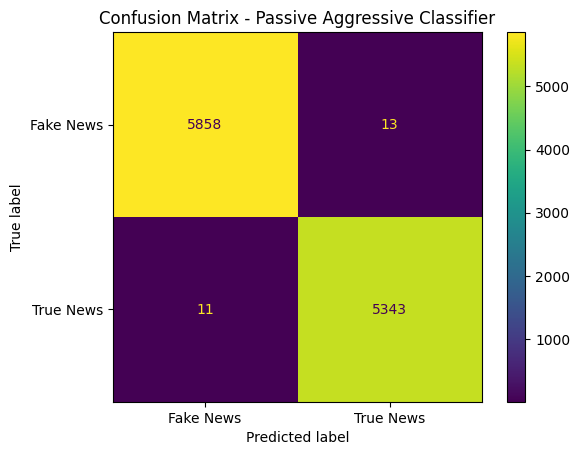

In [15]:
# 15. Confusion Matrix for Best Model

cm = confusion_matrix(y_test, best_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake News", "True News"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [16]:
# 16. Cross Validation on Best Model

# This gives a more reliable performance estimate.

print("\nRunning 5-fold cross-validation on the best model...")

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCross-validation scores:", cv_scores)
print(f"Average CV Accuracy: {cv_scores.mean() * 100:.2f}%")


Running 5-fold cross-validation on the best model...

Cross-validation scores: [0.99699332 0.99755011 0.99721604 0.99844081 0.99721573]
Average CV Accuracy: 99.75%


In [17]:
# 17. Prediction Function

def predict_news(news_text):
    cleaned_news = clean_text(news_text)

    prediction = best_model.predict([cleaned_news])[0]

    if prediction == 0:
        label = "Fake News"
    else:
        label = "True News"

    print("\n" + "=" * 80)
    print("Input News:")
    print(news_text)

    print("\nPrediction:", label)

    model_step = best_model.named_steps["model"]

    if hasattr(model_step, "predict_proba"):
        probability = best_model.predict_proba([cleaned_news])[0]
        confidence = max(probability) * 100
        print(f"Confidence: {confidence:.2f}%")
    else:
        print("Confidence score is not available for this model.")

    print("=" * 80)

In [18]:
# 18. Manual Testing

print("\nModel is ready for manual testing.")

sample_news = """
NASA confirms that its latest mission has successfully collected scientific data
from space and researchers are now analyzing the results.
"""

predict_news(sample_news)


Model is ready for manual testing.

Input News:

NASA confirms that its latest mission has successfully collected scientific data
from space and researchers are now analyzing the results.


Prediction: Fake News
Confidence score is not available for this model.


In [19]:
# 19. Test Your Own News

your_news = """
Enter or paste your news article here.
"""

predict_news(your_news)


Input News:

Enter or paste your news article here.


Prediction: Fake News
Confidence score is not available for this model.


In [20]:
# 20. Optional Interactive Testing

while True:
    choice = input("\nDo you want to test another news article? yes/no: ").strip().lower()

    if choice == "yes":
        user_news = input("\nPaste the news article here:\n")
        predict_news(user_news)

    elif choice == "no":
        print("\nTesting completed.")
        break

    else:
        print("Please type yes or no.")


Do you want to test another news article? yes/no: yes

Paste the news article here:
A viral online report claims that doctors have discovered a secret natural drink that can permanently cure cancer, diabetes, heart disease, and all viral infections within 24 hours. The article says the treatment has been hidden from the public by hospitals and pharmaceutical companies because it would make all modern medicine unnecessary.  The report provides no names of researchers, no published medical study, and no official statement from any health organization. It urges readers to buy the drink immediately before it is banned worldwide.

Input News:
A viral online report claims that doctors have discovered a secret natural drink that can permanently cure cancer, diabetes, heart disease, and all viral infections within 24 hours. The article says the treatment has been hidden from the public by hospitals and pharmaceutical companies because it would make all modern medicine unnecessary.  The report